(w90-nb)=
# Wannier90 example with silicon

In [1]:
from pythtb import W90 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
silicon = W90("silicon_w90", "si")

In [3]:
# hard coded fermi level in eV
fermi_ev = 6.2285135

In [4]:
# all pair distances between the orbitals
print("Shells:\n", silicon.shells())

Shells:
 [ 0.    1.3   1.96  2.35  2.51  2.97  3.18  3.36  3.66  3.82  3.93  4.03
  4.29  4.48  4.57  4.61  4.83  4.97  5.12  5.29  5.32  5.4   5.42  5.48
  5.52  5.55  5.74  5.89  5.95  6.13  6.16  6.27  6.33  6.36  6.39  6.52
  6.55  6.61  6.63  6.74  6.89  7.07  7.1   7.22  7.25  7.39  7.44  7.56
  7.58  7.63  7.69  7.72  7.74  7.77  7.88  7.9   7.99  8.04  8.17  8.19
  8.27  8.31  8.32  8.34  8.36  8.47  8.49  8.53  8.55  8.59  8.74  8.78
  8.81  8.85  8.92  8.94  9.02  9.11  9.15  9.19  9.31  9.35  9.36  9.44
  9.46  9.53  9.55  9.57  9.64  9.72  9.79  9.81  9.88  9.92 10.04 10.29
 10.3  10.4  10.44 10.52 10.54 10.62 10.76 10.8  10.84 10.87 10.99 11.08
 11.18 11.21 11.26 11.29 11.38 11.46 11.72 11.75 12.23 12.24 12.43 13.08
 13.2  13.28 13.45]


We can look at how the Hamiltonian matrix elements generated by Wannier90 decay with distance. This will help us determine the cutoff radius to use in a tight-binding model constructed with `pythtb`. Most hoppings are above $1$ meV, so we will use this as our curtoff energy in this example.

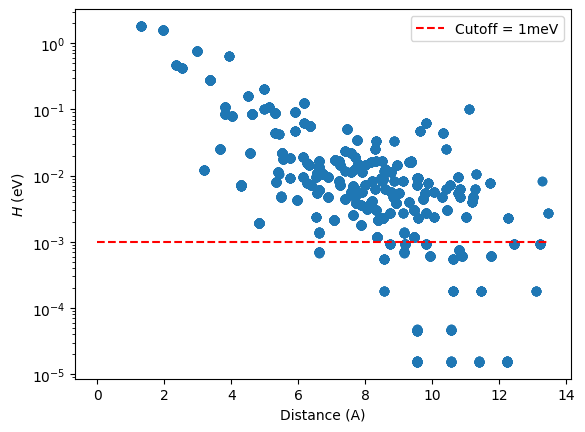

In [5]:
# plot hopping terms as a function of distance on a log scale
(dist, ham) = silicon.dist_hop()
fig, ax = plt.subplots()
ax.scatter(dist, np.abs(ham))
ax.hlines(1e-3, xmin=0, xmax=max(dist), colors='r', linestyles='dashed', label='Cutoff = 1meV')
ax.legend()
ax.set_xlabel("Distance (A)")
ax.set_ylabel(r"$H$ (eV)")
ax.set_yscale('log')

Now, we will generate the tight-binding model for silicon using the Wannier90 output files. This will use the Hamiltonian matrix elements generated by Wannier90 to create a `TBModel` object in `pythtb`.

:::{tip}
It is advised to save the tight-binding model to disk with the cPickle module:
```python
import cPickle
cPickle.dump(my_model, open("store.pkl", "wb"))
```
Later one can load in the model from disk in a separate script with
```python
my_model = cPickle.load(open("store.pkl", "rb"))
```
:::

In [18]:
# get tb model in which some small terms are ignored
my_model = silicon.model(
    zero_energy=fermi_ev,
    min_hopping_norm=1e-3,
)

# Band comparison

First, we will obtain the band structure from the Wannier90 calculation. To do this, we call the `W90.w90_bands` function, which reads the `si_band.dat`, `si_band.kpt` and `si.win` files to extract the band energies and k-point path used in the Wannier90 calculation. Setting `return_k_dist = True` returns the cumulative distance along the k-point path, which we will use for plotting. Setting `return_k_nodes = True` returns the fractional coordinates of the high-symmetry k-points along the path, as well as their labels.

:::{hint}
Small discrepancies in the plot may arise due to the terms that were ignored in the silicon.model function call above.
:::

In [26]:
( w90_kpt, w90_evals, 
  w90_k_dist, w90_k_nodes, w90_k_labels
 ) = silicon.w90_bands(return_k_dist=True, return_k_nodes=True)

print("k-point labels:", w90_k_labels)
print("k-point nodes (fractional):\n", w90_k_nodes)

k-point labels: ['$L$', '$\\Gamma$', '$X$', '$X$', '$K$', '$\\Gamma$']
k-point nodes (fractional):
 [[ 0.5    0.5    0.5  ]
 [ 0.     0.     0.   ]
 [ 0.5    0.     0.5  ]
 [ 0.5   -0.5    0.   ]
 [ 0.375 -0.375  0.   ]
 [ 0.     0.     0.   ]]


For plotting purposes, we also need to know the cumulative distance along the k-point path at each high-symmetry k-point node, which we compute below.

In [11]:
k_vec, k_dist, k_node_dist = my_model.k_path(w90_k_nodes, nk=500, report=False)

Next, we will solve and plot the `TBModel` on the same path as used in Wannier90. This allows us to directly compare the two band structures.

In [12]:
int_evals = my_model.solve_ham(w90_kpt)

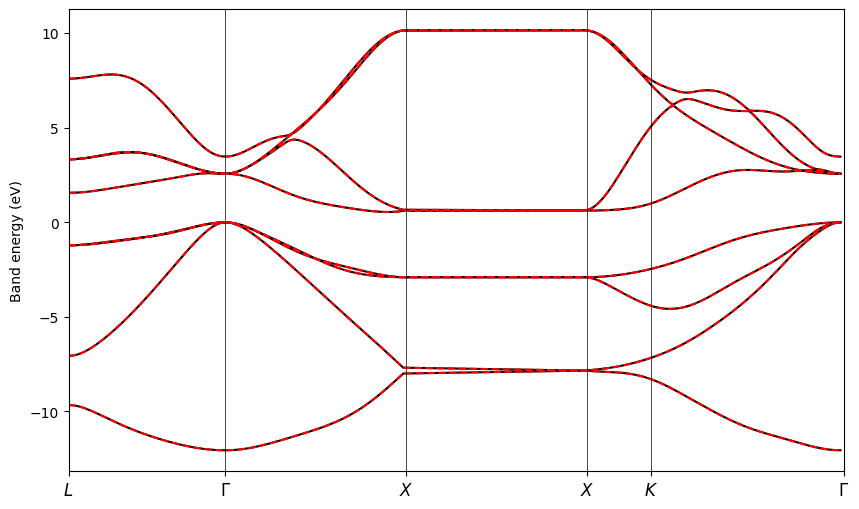

In [13]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(w90_k_dist, w90_evals[:, 0] - fermi_ev, "k-", zorder=0, label="Wannier90")
ax.plot(w90_k_dist, w90_evals[:, 1:] - fermi_ev, "k-", zorder=0)
ax.plot(w90_k_dist, int_evals[:, 0], "r--", zorder=1, label="TBModel")
ax.plot(w90_k_dist, int_evals[:, 1:], "r--", zorder=1)

# set x-ticks at k-point nodes
ax.set_xticks(k_node_dist)
for n in range(len(w90_k_nodes)):
    ax.axvline(x=k_node_dist[n], linewidth=0.5, color="k", zorder=1)
ax.set_xticklabels(w90_k_labels, size=12)
ax.set_xlim(k_node_dist[0], k_node_dist[-1])
ax.set_ylabel("Band energy (eV)")
plt.show()

Shells:
 [ 0.    0.63  1.27  1.84  2.24  2.41  2.55  2.73  3.18  3.26  3.37  3.54
  3.62  3.82  3.87  3.94  4.02  4.14  4.17  4.24  4.42  4.45  4.58  4.59
  4.69  4.77  4.78  4.97  5.02  5.03  5.08  5.26  5.4   5.43  5.49  5.54
  5.55  5.63  5.84  5.86  5.91  5.97  6.07  6.11  6.12  6.24  6.27  6.31
  6.36  6.37  6.46  6.5   6.61  6.62  6.64  6.68  6.73  6.8   6.82  6.86
  7.    7.04  7.08  7.09  7.15  7.17  7.21  7.32  7.34  7.38  7.42  7.53
  7.63  7.64  7.66  7.69  7.7   7.73  7.74  7.85  7.95  7.97  8.01  8.05
  8.11  8.12  8.16  8.25  8.27  8.3   8.34  8.35  8.42  8.45  8.53  8.59
  8.68  8.7   8.73  8.82  8.84  8.86  8.87  8.9   8.91  8.97  9.    9.1
  9.14  9.17  9.18  9.23  9.27  9.35  9.36  9.37  9.4   9.43  9.44  9.49
  9.5   9.53  9.61  9.63  9.65  9.68  9.69  9.75  9.78  9.86  9.87  9.88
  9.9   9.94  9.98  9.99 10.   10.03 10.1  10.11 10.15 10.18 10.23 10.24
 10.26 10.27 10.35 10.36 10.38 10.41 10.42 10.46 10.47 10.5  10.57 10.58
 10.61 10.64 10.69 10.7  10.73 10.8  10.81 

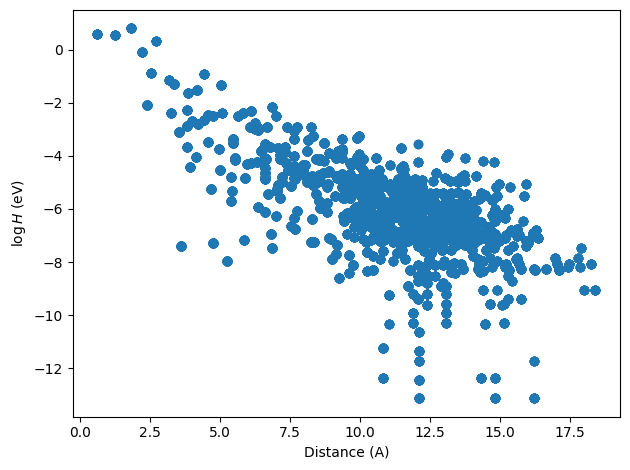

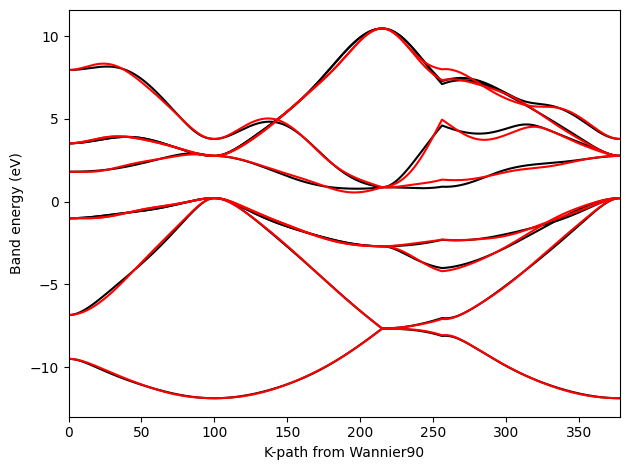

In [2]:
#!/usr/bin/env python

# Copyright under GNU General Public License 2010, 2012, 2016
# by Sinisa Coh and David Vanderbilt (see gpl-pythtb.txt)

from __future__ import print_function
from pythtb import * # import TB model class
import matplotlib.pyplot as plt

# read output from Wannier90 that should be in folder named "example_a"
# see instructions above for how to obtain the example output from Wannier90
# for testing purposes
silicon=w90(r"silicon_w90",r"si")

# hard coded fermi level in eV
fermi_ev=0.62285135E+01

# all pair distances berween the orbitals
print("Shells:\n",silicon.shells())

# plot hopping terms as a function of distance on a log scale
(dist,ham)=silicon.dist_hop()
fig, ax = plt.subplots()
ax.scatter(dist,np.log(np.abs(ham)))
ax.set_xlabel("Distance (A)")
ax.set_ylabel(r"$\log H$ (eV)")
fig.tight_layout()
fig.savefig("silicon_dist_ham.pdf")

# get tb model in which some small terms are ignored
my_model=silicon.model(zero_energy=fermi_ev)

# in the case that all steps up to now take a lot of computer time
# it is advised to save tb model to disk with cPickle module:
#   import cPickle
#   cPickle.dump(my_model,open("store.pkl","wb"))
# Later one can load in the model from disk in a separate script with
#   my_model=cPickle.load(open("store.pkl","rb"))

# solve and plot on the same path as used in wannier90
# small discrepancy in the plot is there because of the terms that
# were ignore in the silicon.model function call above
#
fig, ax = plt.subplots()
(w90_kpt,w90_evals)=silicon.w90_bands_consistency()
for i in range(w90_evals.shape[0]):
    ax.plot(list(range(w90_evals.shape[1])),w90_evals[i]-fermi_ev,"k-",zorder=-100)
# now interpolate from the model on the same path in k-space 
int_evals=my_model.solve_all(w90_kpt)
for i in range(int_evals.shape[0]):
    ax.plot(list(range(int_evals.shape[1])),int_evals[i],"r-",zorder=-50)
ax.set_xlim(0,int_evals.shape[1]-1)
ax.set_xlabel("K-path from Wannier90")
ax.set_ylabel("Band energy (eV)")
fig.tight_layout()
# fig.savefig("silicon.pdf")
